In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

from dataset_classes import ISO_NE, AT, SH_Dataset


ISO_NE_PATH = r"C:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\data\iso_ne\selected_data_ISONE.csv"
AT_PATH     = r"C:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\data\at\AT Dataset.csv"
SH_PATH     = r"C:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\data\sh\sh_dataset.csv"


T_IN, T_OUT = 72, 240

In [4]:
iso_ds = ISO_NE(ISO_NE_PATH, T_in=T_IN, T_out=T_OUT, lag_hours = [1, 12, 24, 168], rolling_windows = [12, 24])
at_ds  = AT(AT_PATH,         T_in=T_IN, T_out=T_OUT, lag_hours = [1, 12, 24, 168], rolling_windows = [12, 24])
sh_ds  = SH_Dataset(SH_PATH, T_in=T_IN, T_out=T_OUT, lag_hours = [1, 12, 24, 168], rolling_windows = [12, 24])

datasets = {
    "ISO-NE": iso_ds.df_numeric,
    "AT":     at_ds.df_numeric,
    "SH":     sh_ds.df_numeric,
}

Loaded dataset with 19 features (target=demand), total rows=103608
Loaded dataset with 18 features (target=demand), total rows=52440
Loaded dataset with 25 features (target=load), total rows=17258


In [5]:
def plot_corr_heatmaps(df, dataset_name, method="pearson", figsize_scale=0.55):
    if method == "pearson":
        corr = df.corr(method="pearson")
        title_method = "Pearson"
    elif method == "spearman":
        corr = df.corr(method="spearman")
        title_method = "Spearman"
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    n = len(corr)
    fig_size = max(8, n * figsize_scale)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4,
        annot_kws={"size": max(6, 10 - n // 4)},
        ax=ax,
        cbar_kws={"shrink": 0.75, "label": f"{title_method} r"},
    )

    ax.set_title(f"{dataset_name} — {title_method} Correlation", fontsize=14, pad=12)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

    plt.tight_layout()
    out_path = f"{dataset_name}_{method}_corr.pdf"
    plt.savefig(out_path, format="pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}\n")

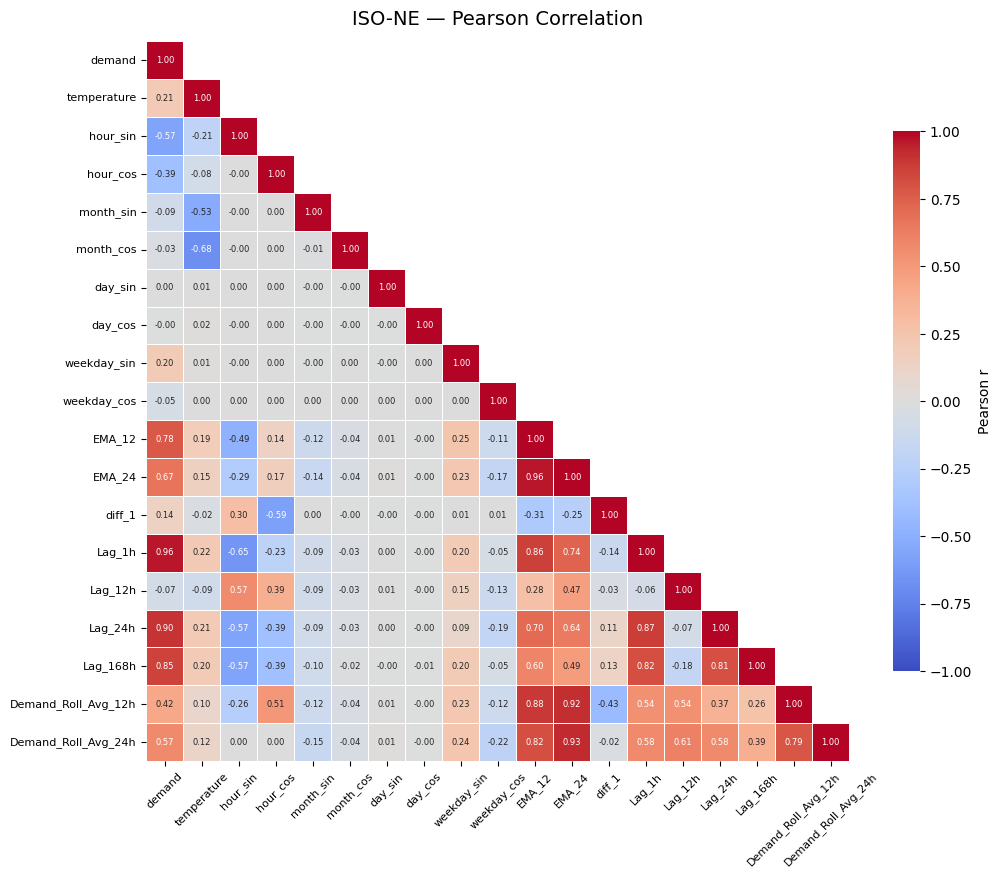

Saved: ISO-NE_pearson_corr.pdf



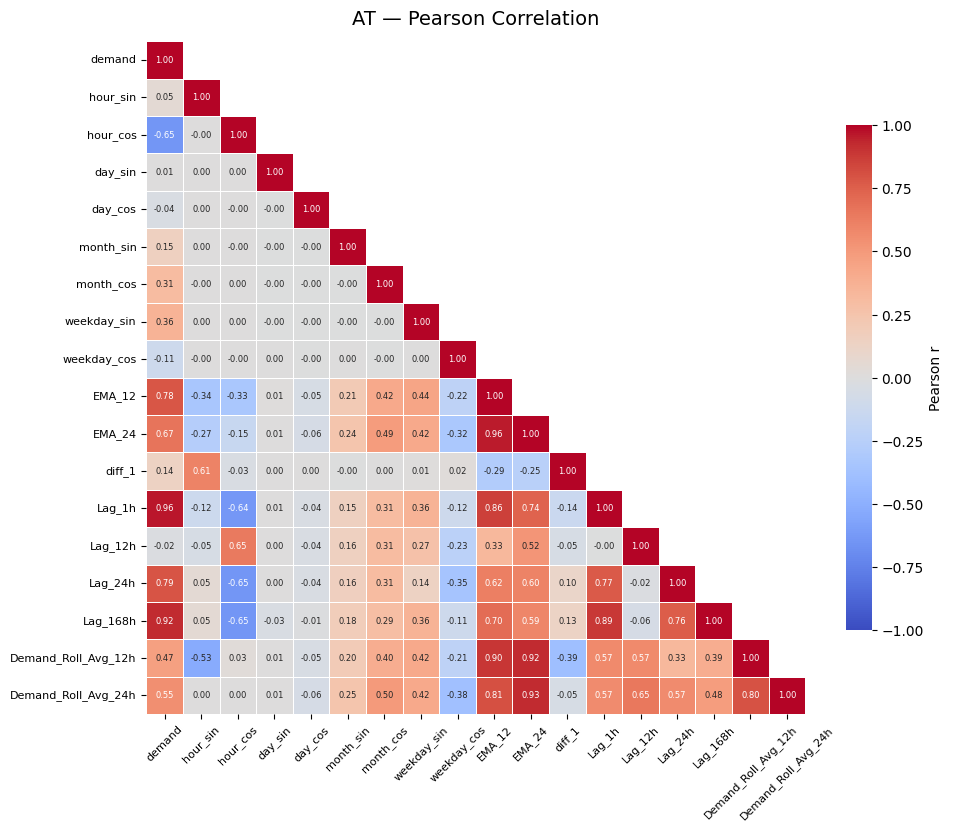

Saved: AT_pearson_corr.pdf



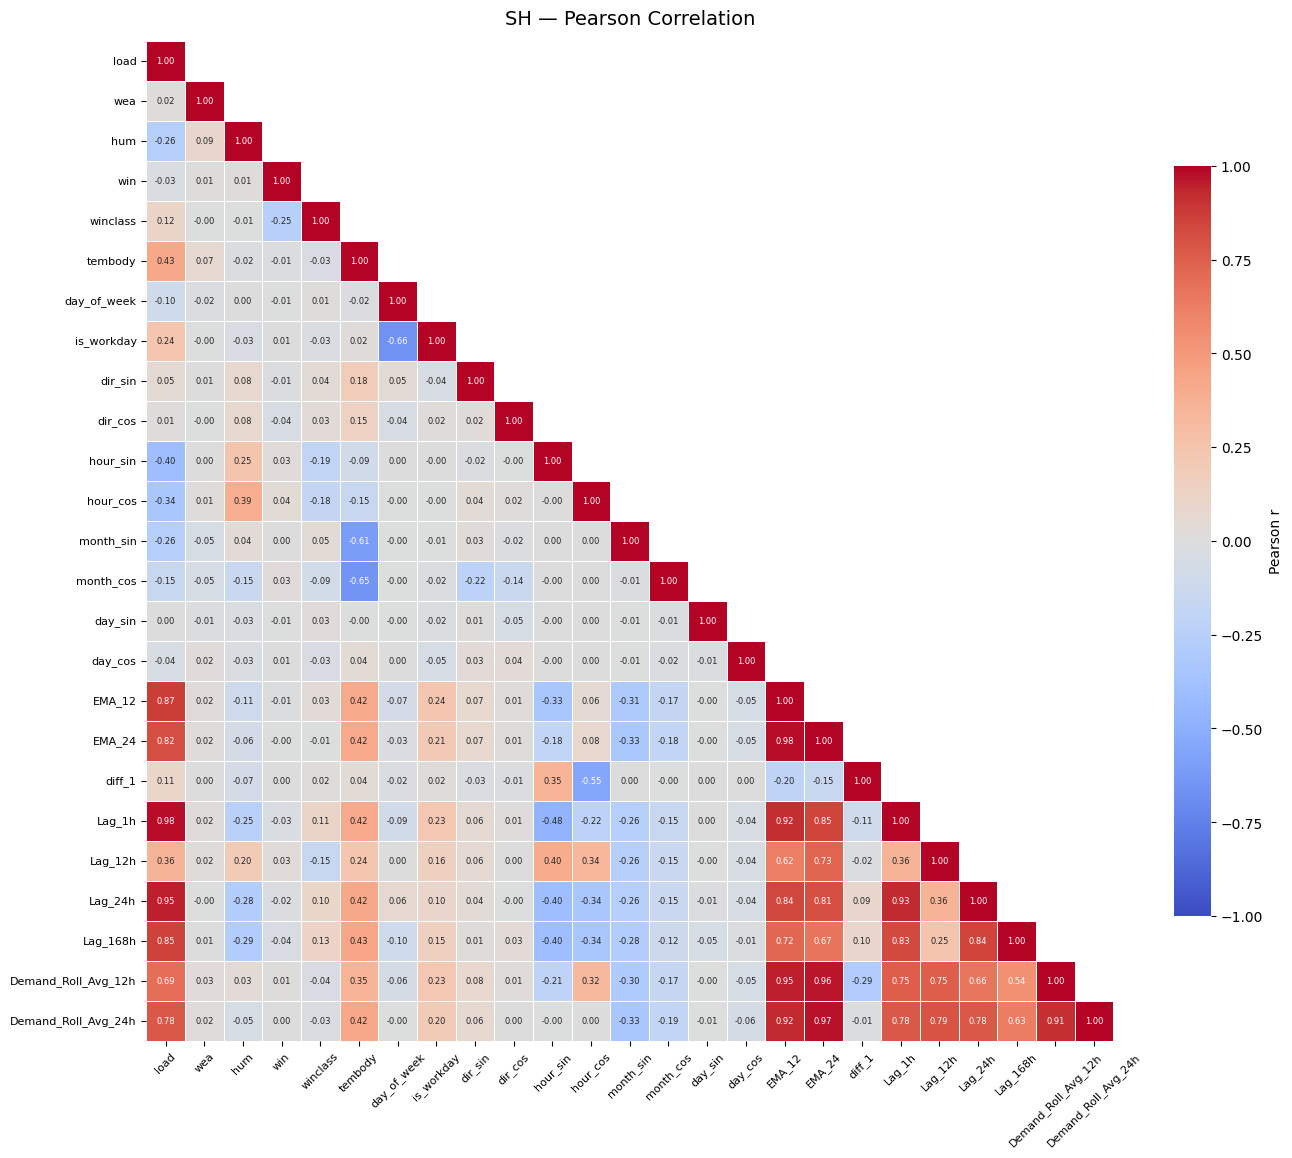

Saved: SH_pearson_corr.pdf



In [6]:
for name, df in datasets.items():
    plot_corr_heatmaps(df, dataset_name=name, method="pearson")

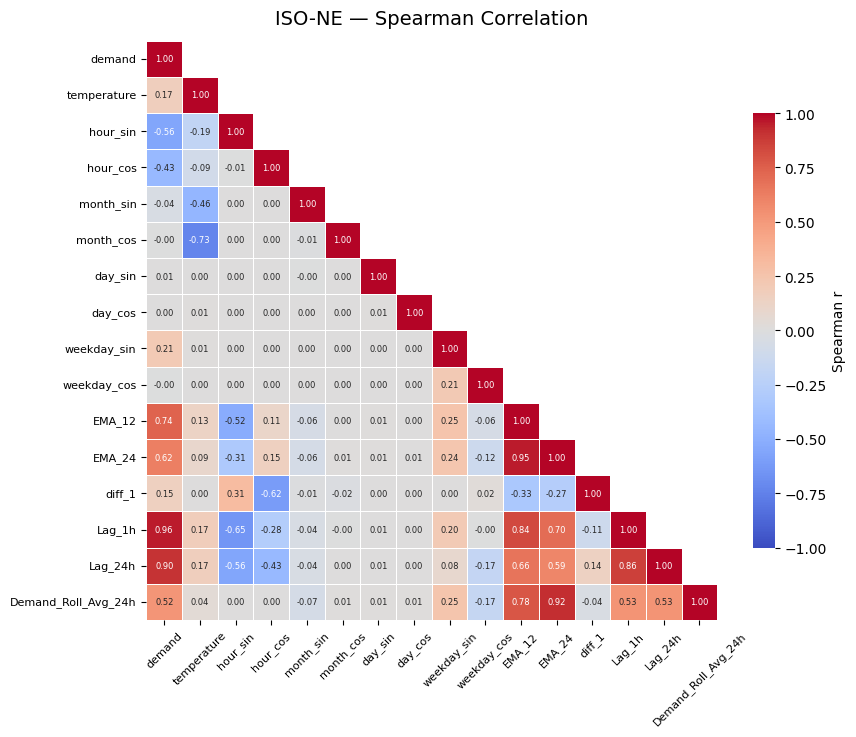

Saved: ISO-NE_spearman_corr.pdf



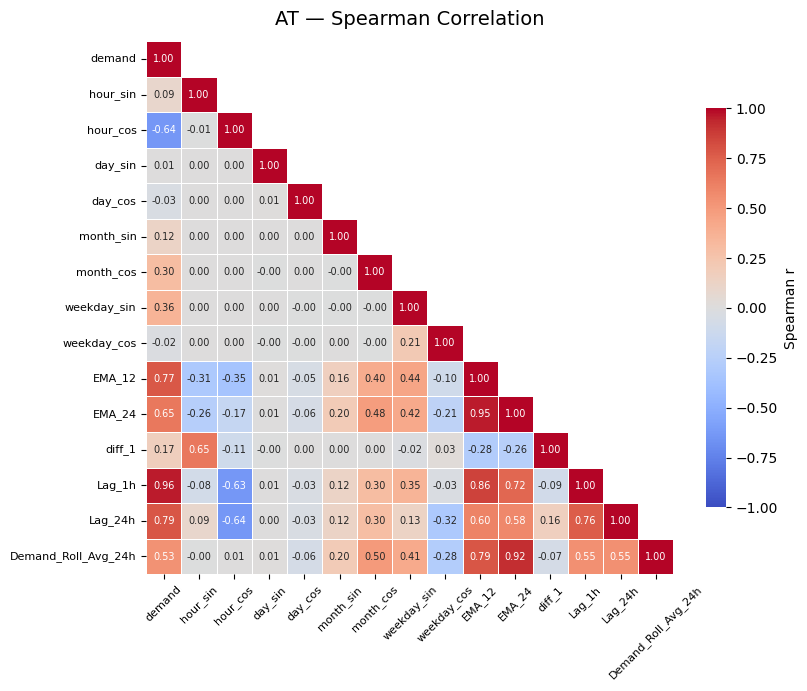

Saved: AT_spearman_corr.pdf



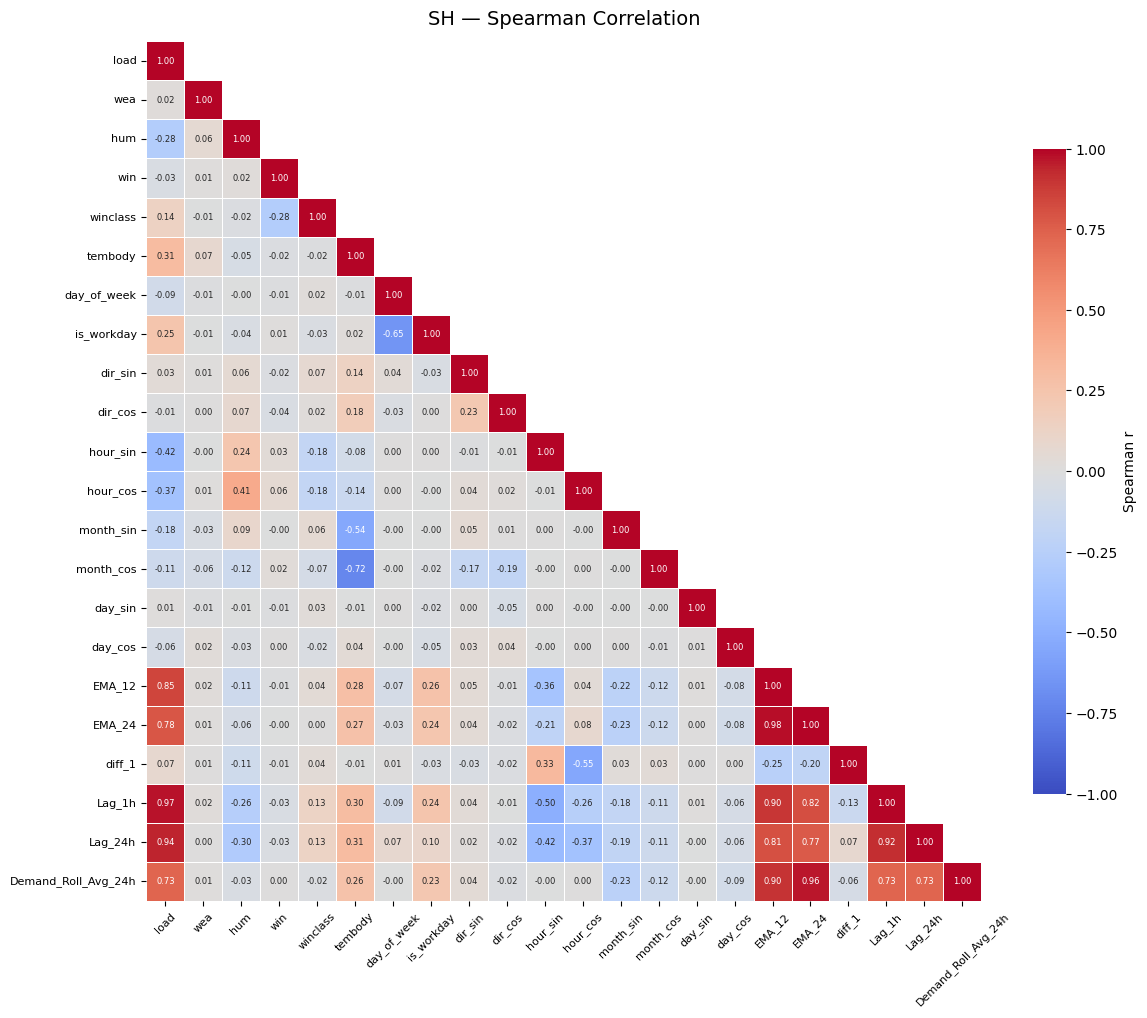

Saved: SH_spearman_corr.pdf



In [5]:
for name, df in datasets.items():
    plot_corr_heatmaps(df, dataset_name=name, method="spearman")